# GLD (SPDR Gold Shares)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.stats import shapiro, kstest
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Path to the gld data file
file_path = "gld.us.txt"

# Load the file
df = pd.read_csv(file_path, delimiter=',')

In [3]:
file_path = "GLD_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

#### Descriptive statistics

In [4]:
df.describe()

,Open,High,Low,Close,Volume,OpenInt
count,3201.000000,3201.000000,3201.000000,3201.000000,3.201000e+03,3201.0
mean,108.184983,108.768326,107.545810,108.182371,1.001952e+07,0.0
std,34.335915,34.458401,34.188675,34.333828,7.525031e+06,0.0
min,41.410000,41.650000,41.330000,41.530000,3.193000e+05,0.0
25%,83.560000,84.580000,82.210000,83.460000,5.196958e+06,0.0
50%,115.130000,115.770000,114.550000,115.150000,8.285855e+06,0.0
75%,127.240000,127.890000,126.730000,127.400000,1.248855e+07,0.0
max,184.580000,185.850000,182.100000,184.590000,9.378378e+07,0.0


In [5]:
categorized_df.describe()

,Open,High,Low,Close,Volume
count,2881.000000,2881.000000,2881.000000,2881.000000,2.881000e+03
mean,110.671552,111.242173,110.071783,110.691718,9.240075e+06
std,32.058051,32.138978,31.981179,32.077568,4.766528e+06
min,41.450000,41.690000,41.330000,41.620000,2.206203e+06
25%,87.850000,88.670000,87.130000,87.890000,5.490027e+06
50%,116.210000,116.610000,115.615000,116.090000,8.285855e+06
75%,127.620000,128.220000,127.205000,127.660000,1.189712e+07
max,182.820000,183.510000,182.100000,183.240000,2.399548e+07


#### Skewness and elongation analysis

In [6]:
# We are only calculating the “Skewness” and “Kurtosis” for “Volume” as before and after
# cause that’s the only column that we have changed 

print("Volume before:")
print(f"Volume Skewness: {skew(df['Volume'])}")    
print(f"Volume Kurtosis: {kurtosis(df['Volume'])}")

Volume before:
Volume Skewness: 2.729092326348855
Volume Kurtosis: 14.567051271255288


In [7]:
print("Dataset after:\n")

columns_to_check = ['Open', 'Close', 'High', 'Low', 'Volume']

for column in columns_to_check:
    print(f"{column} Skewness: {skew(categorized_df[column])}")
    print(f"{column} Kurtosis: {kurtosis(categorized_df[column])}\n")

Dataset after:

Open Skewness: -0.12836285151776639
Open Kurtosis: -0.6492093265277354

Close Skewness: -0.127022387291288
Close Kurtosis: -0.6502180224630862

High Skewness: -0.12628048467162153
High Kurtosis: -0.6400601707003961

Low Skewness: -0.1324383733283598
Low Kurtosis: -0.6613391798773818

Volume Skewness: 0.8283999355711779
Volume Kurtosis: 0.09847540150660405



#### Statistical hypothesis testing

In [8]:
# To check whether the data follows a normal distribution (Shapiro-Wilk), (nKolmogorov)
stat, p = shapiro(categorized_df['Close'])
print(f"Shapiro-Wilk Test: \nStatistic = {stat} \np-value = {p}")

stat, p = kstest(categorized_df['Close'], 'norm')
print(f"\nKolmogorov-Smirnov Test: \nStatistic = {stat} \np-value = {p}")


# Checking if the average of two columns is different (T-test)
t_stat, p_val = ttest_ind(categorized_df['Open'], categorized_df['Close'])
print(f"\nT-Test: \nStatistic = {t_stat} \np-value = {p_val}")


# Checking the mean difference between multiple columns (Anova)
f_stat, p_val = f_oneway(categorized_df['Open'], categorized_df['Close'], categorized_df['High'])
print(f"\nANOVA Test: \nStatistic = {f_stat} \np-value = {p_val}")


# Checking the independence or relationship between two categorical columns (Chi-Square)
contingency_table = pd.crosstab(categorized_df['High_category'], categorized_df['Volume_category'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Test: \nStatistic = {chi2} \np-value = {p_val}")

Shapiro-Wilk Test: 
Statistic = 0.9687381394025806 
p-value = 1.4396326028213523e-24

Kolmogorov-Smirnov Test: 
Statistic = 1.0 
p-value = 0.0

T-Test: 
Statistic = -0.023867407038923188 
p-value = 0.9809591990435451

ANOVA Test: 
Statistic = 0.2932733685669722 
p-value = 0.7458256537210954

Chi-Square Test: 
Statistic = 8670.457182549597 
p-value = 2.164124645112158e-122


#### Correlation Analysis

Calculating Pearson and Spearman correlation coefficients

In [9]:
# Pearson correlation
pearson_corr, p_val = pearsonr(categorized_df['Low'], categorized_df['Volume'])
print(f"Pearson Correlation: \nCorrelation = {pearson_corr} \np-value = {p_val}")

# Spearman correlation
spearman_corr, p_val = spearmanr(categorized_df['Low'], categorized_df['Volume'])
print(f"\nSpearman Correlation: \nCorrelation = {spearman_corr} \np-value = {p_val}")


Pearson Correlation: 
Correlation = 0.27915470247562674 
p-value = 1.0094664090349758e-52

Spearman Correlation: 
Correlation = 0.310721283986249 
p-value = 1.5998356654392267e-65


In [10]:
# Calculating the correlation matrix
correlation_matrix = categorized_df[['Open', 'Low', 'High', 'Close', 'Volume']].corr(method='pearson')
correlation_matrix

,Open,Low,High,Close,Volume
Open,1.000000,0.999809,0.999854,0.999715,0.285550
Low,0.999809,1.000000,0.999764,0.999835,0.279155
High,0.999854,0.999764,1.000000,0.999871,0.290565
Close,0.999715,0.999835,0.999871,1.000000,0.285135
Volume,0.285550,0.279155,0.290565,0.285135,1.000000


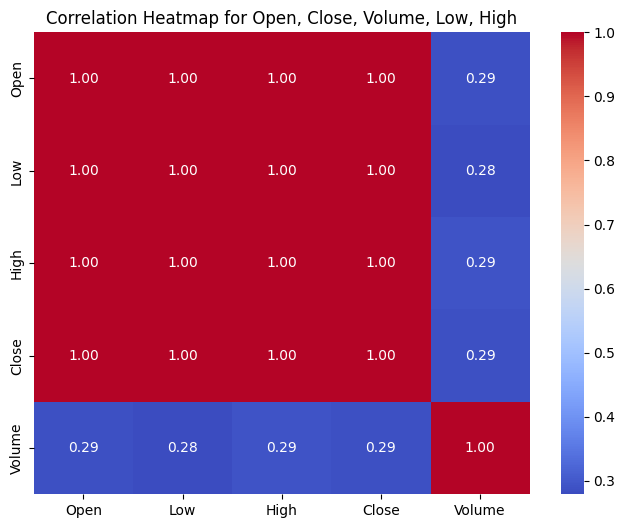

In [11]:
# drawing for heatmap matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap for Open, Close, Volume, Low, High")
plt.show()


In [12]:
# extracting strong correlations
strong_correlations = correlation_matrix[(correlation_matrix > 0.7) | (correlation_matrix < -0.7)]
print("Strong Correlations:")
print(strong_correlations)


Strong Correlations:
            Open       Low      High     Close  Volume
Open    1.000000  0.999809  0.999854  0.999715     NaN
Low     0.999809  1.000000  0.999764  0.999835     NaN
High    0.999854  0.999764  1.000000  0.999871     NaN
Close   0.999715  0.999835  0.999871  1.000000     NaN
Volume       NaN       NaN       NaN       NaN     1.0


#### Dispersion Analysis

In [13]:
dispersion = categorized_df['Volume'].var() / categorized_df['Volume'].mean()
print(f"Dispersion Ratio: {dispersion}")


Dispersion Ratio: 2458832.1666774508


#### Multicollinearity Analysis

In [14]:
X = categorized_df[['Open', 'High', 'Low', 'Close', 'Volume']]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


  feature            VIF
0    Open   77174.003025
1    High  131114.704684
2     Low   78181.399578
3   Close   95167.538465
4  Volume       7.282646


#### Comparative Analysis

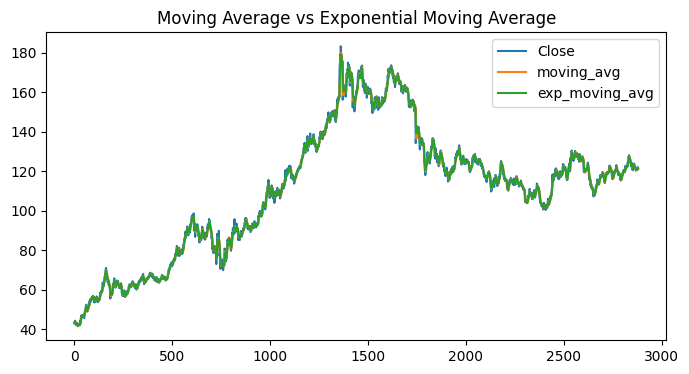

In [15]:
categorized_df['moving_avg'] = categorized_df['Close'].rolling(window=5).mean()
categorized_df['exp_moving_avg'] = categorized_df['Close'].ewm(span=5).mean()

categorized_df[['Close', 'moving_avg', 'exp_moving_avg']].plot(figsize=(8, 4))
plt.title("Moving Average vs Exponential Moving Average")
plt.show()


#### Statistical Regression Analysis

In [16]:
X = categorized_df[['Open', 'High', 'Low']]
y = categorized_df['Close']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.036e+06
Date:                Sat, 23 Nov 2024   Prob (F-statistic):               0.00
Time:                        05:29:38   Log-Likelihood:                -1257.5
No. Observations:                2881   AIC:                             2523.
Df Residuals:                    2877   BIC:                             2547.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0830      0.026     -3.210      0.0

#### Drawing a scatter plot with a regression line

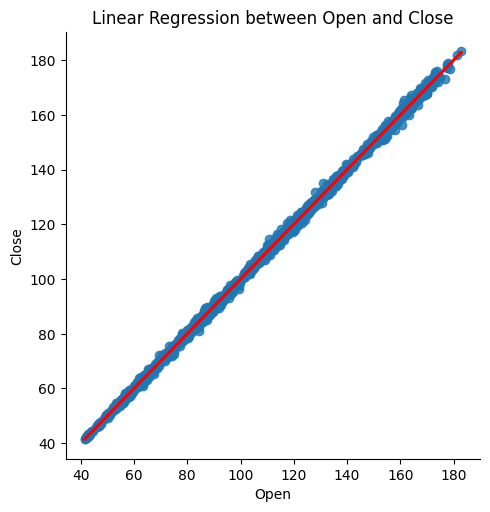

In [17]:
sns.lmplot(x='Open', y='Close', data=categorized_df, line_kws={'color': 'red'})
plt.title("Linear Regression between Open and Close")
plt.show()
